## 6. Sound

### 6.1 Sonogram

In [18]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display



# --- Image export (used by all plots in this notebook) ---

image_output_path = Path("../image-output") # Directory for exported images

# Export button for a matplotlib or Plotly figure (saves only when pressed).
# The format (svg, png, ...) is taken from the filename; dpi only applies to matplotlib raster formats.
# fig and filename can also be functions, so interactive plots export whatever is currently shown.
def make_export_button(fig, filename, dpi=None):
    get_fig = fig if callable(fig) else lambda: fig
    get_filename = filename if callable(filename) else lambda: filename
    file_format = Path(get_filename()).suffix.lstrip('.').lower()
    button = widgets.Button(description=f'Save {file_format.upper()}', icon='download')
    status = widgets.Label()

    def save(_):
        try:
            current = get_fig()
            image_output_path.mkdir(exist_ok=True)
            out_filename = image_output_path / get_filename()
            if hasattr(current, 'write_image'):  # Plotly
                current.write_image(out_filename, format=file_format, width=1200, height=800, scale=1.5)
            else:  # matplotlib
                current.savefig(out_filename, format=file_format, dpi=dpi, bbox_inches="tight")
            status.value = f"Saved {file_format.upper()}: {out_filename}"
        except Exception as e:
            status.value = f"{file_format.upper()} export failed: {e}"

    button.on_click(save)
    return widgets.HBox([button, status])


# --- Configuration ---

AUDIO_PATH = "../data/sound/performanceRoughMix.wav"

# STFT parameters
N_FFT = 4096         # window length in samples (controls frequency resolution)
HOP_LENGTH = 512     # hop between windows in samples (controls time resolution)

# Display parameters
FREQ_SCALE = "mel"   # "mel" for perceptual scaling, "log" for log-frequency, "linear" for Hz
F_MIN = 20           # lowest displayed frequency in Hz
F_MAX = 16000        # highest displayed frequency in Hz
DYN_RANGE = 80       # dynamic range in dB (below peak)
CMAP = "inferno"     # colormap: "inferno", "magma", "viridis", "gray_r" are good options

FIGSIZE = (14, 5)    # figure dimensions in inches


# --- Load audio ---

y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)
duration_min = len(y) / sr / 60
print(f"Loaded: {sr} Hz, {len(y)} samples, {duration_min:.1f} minutes")

duration_sec = len(y) / sr

# --- Compute spectrogram of the whole file (once; the time selector only shows a part of it) ---

if FREQ_SCALE == "mel":
    S = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        fmin=F_MIN, fmax=F_MAX,
        n_mels=512
    )
    y_axis_type = "mel"

else:
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)) ** 2
    y_axis_type = FREQ_SCALE  # "log" or "linear"

# Keep the hop used for this spectrogram (later cells redefine HOP_LENGTH)
spec_hop_length = HOP_LENGTH


# --- Plot ---

spectrogram_output = widgets.Output()

# Keep a reference to the current figure and range so the export button can save it
current_spec_fig = None
current_spec_range = None

def tick_step(span_sec):
    # Pick a "nice" tick spacing that gives at most ~15 ticks
    for step in (1, 2, 5, 10, 20, 50, 100, 200, 500):
        if span_sec / step <= 15:
            return step
    return 1000

def draw_spectrogram(change=None):
    global current_spec_fig, current_spec_range
    start_sec, end_sec = time_selector.value
    if end_sec <= start_sec:
        return

    # Select the frames within the chosen time range; dB relative to the loudest point in the selection
    first_frame = int(start_sec * sr / spec_hop_length)
    last_frame = min(int(end_sec * sr / spec_hop_length) + 1, S.shape[1])
    S_dB = librosa.power_to_db(S[:, first_frame:last_frame], ref=np.max)

    with spectrogram_output:
        spectrogram_output.clear_output(wait=True)

        fig, ax = plt.subplots(figsize=FIGSIZE)

        img = librosa.display.specshow(
            S_dB,
            sr=sr,
            hop_length=spec_hop_length,
            x_axis="time",
            y_axis=y_axis_type,
            ax=ax,
            cmap=CMAP,
            vmin=S_dB.max() - DYN_RANGE,
            vmax=S_dB.max(),
            fmin=F_MIN,
            fmax=F_MAX,
            x_coords=np.linspace(start_sec, end_sec, S_dB.shape[1])
        )

        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Frequency (Hz)")
        ax.set_title(f"Spectrogram ({start_sec}–{end_sec} seconds)")

        step = tick_step(end_sec - start_sec)
        ax.set_xlim(start_sec, end_sec)
        ax.set_xticks(np.arange(np.ceil(start_sec / step) * step, end_sec + 1, step))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}"))

        fig.colorbar(img, ax=ax, format="%+2.0f dB", label="Power (dB)")
        fig.tight_layout()

        current_spec_fig = fig
        current_spec_range = (start_sec, end_sec)

        plt.show()

# Selector for start and end time (in seconds); starts with the whole file
time_selector = widgets.IntRangeSlider(
    value=(0, int(np.ceil(duration_sec))),
    min=0,
    max=int(np.ceil(duration_sec)),
    step=1,
    description='Time (s):',
    continuous_update=False,  # redraw only when the slider is released
    layout=widgets.Layout(width='700px')
)
time_selector.observe(draw_spectrogram, names='value')

# Initial draw of the whole file
draw_spectrogram()

### Export button for the figure (PNG at 1200 dpi)
spec_export = make_export_button(
    lambda: current_spec_fig,
    lambda: f"spectrogram_{current_spec_range[0]}_{current_spec_range[1]}s.png",
    dpi=1200
)

display(widgets.HBox([time_selector, spec_export]))
display(spectrogram_output)

Loaded: 48000 Hz, 34740000 samples, 12.1 minutes


Output()

### 6.2 Perceptual Loudness

In [15]:
"""
Perceptually weighted loudness timeline.
Builds on y, sr already loaded in the spectrogram script.

Requires: pip install pyloudnorm
"""

import numpy as np
import matplotlib.pyplot as plt
import pyloudnorm as pyln
import plotly.graph_objects as go
import plotly.io as pio

# --- Configuration ---

WINDOW_SEC = 3.0    # analysis window (EBU R128 short-term loudness = 3 s)
HOP_SEC = 0.3       # hop between windows — controls time resolution of the curve
FIGSIZE = (14, 4)

# --- Compute loudness contour ---

meter = pyln.Meter(sr, block_size=WINDOW_SEC)

window_samples = int(WINDOW_SEC * sr)
hop_samples = int(HOP_SEC * sr)
n_frames = 1 + (len(y) - window_samples) // hop_samples

loudness = np.full(n_frames, np.nan)
times = np.zeros(n_frames)

print(f"Computing {n_frames} frames — this may take a moment for long recordings...")

for i in range(n_frames):
    start = i * hop_samples
    end = start + window_samples
    L = meter.integrated_loudness(y[start:end])
    if np.isfinite(L):
        loudness[i] = L
    times[i] = (start + end) / 2 / sr

# Handle silent passages where BS.1770 gating returns -inf
floor = np.nanmin(loudness) if np.any(np.isfinite(loudness)) else -70.0
loudness = np.where(np.isfinite(loudness), loudness, floor)

# Convert time axis to minutes for readability
times_min = times / 60

print(f"Done. Range: {np.min(loudness):.1f} to {np.max(loudness):.1f} LUFS")

# --- Plot with Plotly ---
pio.renderers.default = "notebook_connected"

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=times,
    y=np.full_like(times, floor),
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip"
))

fig.add_trace(go.Scatter(
    x=times,
    y=loudness,
    mode="lines",
    name="Short-term loudness",
    line=dict(color="steelblue", width=1),
    fill="tonexty",
    fillcolor="rgba(70, 130, 180, 0.18)",
    hovertemplate="Time: %{x:.1f} s<br>Loudness: %{y:.1f} LUFS<extra></extra>"
))

fig.update_layout(
    title="Short-Term Loudness (ITU-R BS.1770, 3 s window)",
    width=1200,
    height=400,
    template="plotly_white",
    paper_bgcolor="white",
    plot_bgcolor="white",
    xaxis=dict(
        title="Time (seconds)",
        range=[times[0], times[-1]],
        tickmode="array",
        tickvals=np.arange(0, times[-1] + 50, 50),
        ticktext=[str(int(t)) for t in np.arange(0, times[-1] + 50, 50)]
    ),
    yaxis=dict(
        title="Loudness (LUFS)"
    )
)

### Display the figure with its export button (make_export_button is defined in 6.1)
fig.show()
display(make_export_button(fig, "loudness.svg"))

Computing 2403 frames — this may take a moment for long recordings...
Done. Range: -70.0 to -25.1 LUFS


### 6.3 Textural event density

In [16]:
"""
Onset density timeline.
Builds on y, sr already loaded in the spectrogram script.

Detects spectral-flux onsets and computes their density over time
as an indicator of textural event rate.
"""

import numpy as np
import librosa
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# --- Configuration ---

# Onset detection parameters
HOP_LENGTH = 512           # hop for onset strength computation
ONSET_DELTA = 0.02         # peak-picking threshold — raise to suppress weak onsets,
                           # lower to capture more; will need tuning per recording

# Density computation
DENSITY_WINDOW_SEC = 3.0   # sliding window width for counting onsets
DENSITY_HOP_SEC = 0.1      # hop between density measurements

FIGSIZE = (14, 4)


# --- Detect onsets ---

onset_frames = librosa.onset.onset_detect(
    y=y, sr=sr,
    hop_length=HOP_LENGTH,
    delta=ONSET_DELTA,
    wait=10               # minimum frames between onsets (prevents double-triggering)
)

onset_times = librosa.frames_to_time(onset_frames, sr=sr, hop_length=HOP_LENGTH)

print(f"Detected {len(onset_times)} onsets over {len(y)/sr:.1f} seconds")
print(f"Mean rate: {len(onset_times) / (len(y)/sr):.1f} onsets/s")


# --- Compute onset density over time ---

window_samples_t = DENSITY_WINDOW_SEC
hop_t = DENSITY_HOP_SEC
duration = len(y) / sr

# Generate evaluation times (center of each window)
eval_times = np.arange(
    DENSITY_WINDOW_SEC / 2,
    duration - DENSITY_WINDOW_SEC / 2,
    DENSITY_HOP_SEC
)

# Count onsets falling within each window
density = np.zeros(len(eval_times))

for i, t in enumerate(eval_times):
    window_start = t - DENSITY_WINDOW_SEC / 2
    window_end = t + DENSITY_WINDOW_SEC / 2
    count = np.sum((onset_times >= window_start) & (onset_times < window_end))
    density[i] = count / DENSITY_WINDOW_SEC   # normalize to onsets per second

eval_times_min = eval_times / 60


# --- Plot ---

pio.renderers.default = "notebook_connected"

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eval_times,
    y=np.zeros_like(eval_times),
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip"
))

fig.add_trace(go.Scatter(
    x=eval_times,
    y=density,
    mode="lines",
    name="Onset density",
    line=dict(color="darkorange", width=1),
    fill="tonexty",
    fillcolor="rgba(255, 140, 0, 0.18)",
    hovertemplate="Time: %{x:.1f} s<br>Density: %{y:.2f} onsets/s<extra></extra>"
))

fig.update_layout(
    title=f"Onset Density ({DENSITY_WINDOW_SEC:.0f} s window, δ = {ONSET_DELTA})",
    width=1200,
    height=400,
    template="plotly_white",
    paper_bgcolor="white",
    plot_bgcolor="white",
    xaxis=dict(
        title="Time (seconds)",
        range=[eval_times[0], eval_times[-1]],
        tickmode="array",
        tickvals=np.arange(0, eval_times[-1] + 50, 50),
        ticktext=[str(int(t)) for t in np.arange(0, eval_times[-1] + 50, 50)]
    ),
    yaxis=dict(
        title="Onset density (onsets / s)",
        range=[0, density.max() * 1.05]
    )
)

### Display the figure with its export button (make_export_button is defined in 6.1)
fig.show()
display(make_export_button(fig, "texturalEventDensity.svg"))

Detected 2521 onsets over 723.8 seconds
Mean rate: 3.5 onsets/s


## 6.4 Tonal vs. Noise

Computing harmonic-percussive separation — this may take a moment for long recordings...
Done. Mean spectral flatness: 0.002
Mean harmonic proportion: 0.776


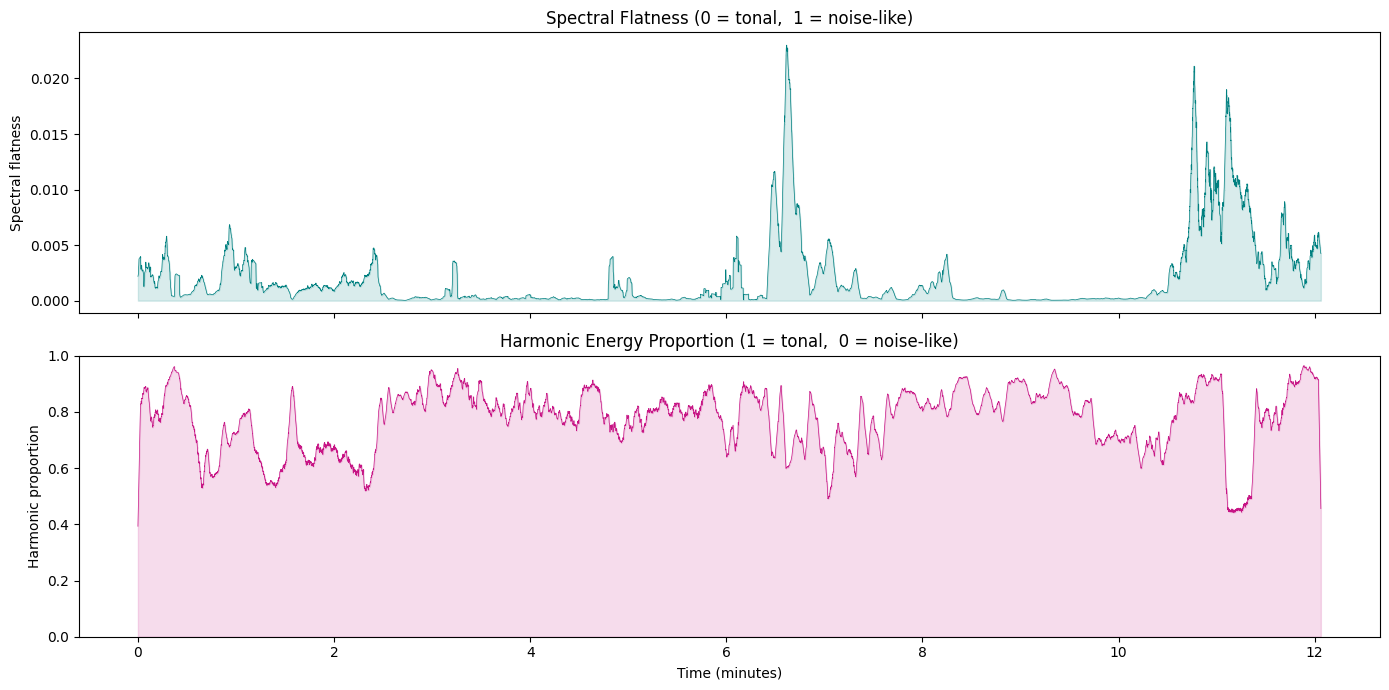

In [17]:
"""
Tonal vs. noise character analysis.
Two complementary measures:

1. Spectral flatness (Wiener entropy)
   Ratio of geometric to arithmetic mean of the power spectrum per frame.
   0 = purely tonal, 1 = noise-like. Computed frame by frame, then smoothed.

2. Harmonic energy proportion via HPSS
   Decomposes the signal into harmonic and percussive components, then
   tracks the proportion of harmonic energy over time.
   1 = fully tonal, 0 = fully noise-like.

Note that the two scales run in opposite directions.

Builds on y, sr already loaded.
"""

import numpy as np
import librosa
import matplotlib.pyplot as plt

# --- Configuration ---

HOP_LENGTH = 512
SMOOTHING_WINDOW_SEC = 3.0    # moving-average width for both measures,
                               # matched to the loudness analysis window
FIGSIZE = (14, 7)


# --- 1. Spectral flatness ---

flatness = librosa.feature.spectral_flatness(y=y, hop_length=HOP_LENGTH)[0]
flatness_times = librosa.frames_to_time(
    np.arange(len(flatness)), sr=sr, hop_length=HOP_LENGTH
)

# Smooth to match temporal scale of the other timeline analyses
smooth_frames = int(SMOOTHING_WINDOW_SEC * sr / HOP_LENGTH)
kernel = np.ones(smooth_frames) / smooth_frames

flatness_smooth = np.convolve(flatness, kernel, mode="same")


# --- 2. Harmonic-percussive separation and energy ratio ---

print("Computing harmonic-percussive separation — this may take a moment "
      "for long recordings...")

y_harmonic, y_percussive = librosa.effects.hpss(y)

# RMS energy of each component
rms_h = librosa.feature.rms(y=y_harmonic, hop_length=HOP_LENGTH)[0]
rms_p = librosa.feature.rms(y=y_percussive, hop_length=HOP_LENGTH)[0]
rms_times = librosa.frames_to_time(
    np.arange(len(rms_h)), sr=sr, hop_length=HOP_LENGTH
)

# Harmonic proportion: H / (H + P)
eps = 1e-10
harmonic_proportion = rms_h / (rms_h + rms_p + eps)
harmonic_smooth = np.convolve(harmonic_proportion, kernel, mode="same")

print(f"Done. Mean spectral flatness: {np.mean(flatness_smooth):.3f}")
print(f"Mean harmonic proportion: {np.mean(harmonic_smooth):.3f}")


# --- Plot ---

times_min_flat = flatness_times / 60
times_min_hpss = rms_times / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

# Spectral flatness (0 = tonal, 1 = noise-like)
ax1.plot(times_min_flat, flatness_smooth, linewidth=0.5, color="teal")
ax1.fill_between(times_min_flat, 0, flatness_smooth, alpha=0.15, color="teal")
ax1.set_ylabel("Spectral flatness")
ax1.set_title("Spectral Flatness (0 = tonal,  1 = noise-like)")
# ax1.set_ylim(0, 1)

# Harmonic proportion (1 = tonal, 0 = noise-like)
ax2.plot(times_min_hpss, harmonic_smooth, linewidth=0.5, color="mediumvioletred")
ax2.fill_between(times_min_hpss, 0, harmonic_smooth, alpha=0.15, color="mediumvioletred")
ax2.set_xlabel("Time (minutes)")
ax2.set_ylabel("Harmonic proportion")
ax2.set_title("Harmonic Energy Proportion (1 = tonal,  0 = noise-like)")
ax2.set_ylim(0, 1)

fig.tight_layout()
plt.show()

### Export button for the figure (make_export_button is defined in 6.1)
display(make_export_button(fig, "tonalVsNoise.svg"))